### 1. Data Ingestion & Environment Initialization
* **Vectorized I/O:** Leveraging `pandas` for $O(N)$ CSV parsing. *(Note: For >10GB datasets, we would transition to `pyarrow` or chunked Dask processing to prevent OOM errors).*
* **Path Normalization:** Using raw string literals (`r''`) to bypass Windows escape character conflicts in file paths.
* **Execution Hygiene:** Suppressing `SettingWithCopyWarning` to maintain a clean execution log during batch metric extraction.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

file_path = r'F:\ml_clean_project\data\defect_annotations.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded. Shape: {df.shape}")
display(df.head())

Dataset loaded. Shape: (442, 3)


,filename,polygon_xy,class
0,img_0148.png,121.1 742.5 110.4 745.9 99.1 746.5 91.4 737.4 ...,Bubble
1,img_0118.png,1053.8 720.2 984.5 876.2 980.9 874.6 1050.9 718.9,Scratch
2,img_0062.png,326.7 764.1 374.3 782.2 419.8 805.1 466.9 824....,Scratch
3,img_0091.png,36.5 399.4 36.6 377.4 59.3 359.3 83.7 358.8 91...,Dent
4,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent


### 2. Computational Geometry & Topological Validation
* **Coordinate Parsing:** Slicing the flattened 1D array (`coords[0::2]`) to separate X and Y axes in $O(N)$ time complexity.
* **Isoperimetric Inequality (Compactness):** Calculating $C = \frac{4\pi A}{P^2}$. A perfect circle yields $C=1.0$; elongated defects approach $C \to 0$. This strict geometric invariant detects mislabeled classes.
* **Topological Integrity:** Using `shapely` to enforce the OGC Simple Features specification. This catches self-intersecting "bowtie" polygons that cause fatal `NaN` errors during mask rasterization in PyTorch.
* **Bounding Box Aspect Ratio (AR):** Calculating the ratio of the minimum area bounding rectangle to differentiate linear defects (high AR) from radial defects (low AR).

In [6]:
def extract_advanced_metrics(poly_str):
    # 1. Handle missing, NaN, or non-string data gracefully
    if not isinstance(poly_str, str) or pd.isna(poly_str) or poly_str.strip() == "":
        # Return defaults for invalid data: vertex=0, oob=True (flag it), valid=False, metrics=0
        return pd.Series([0, True, False, 0, 0, 0, 0, 0]) 

    try:
        coords = list(map(float, poly_str.split()))
        xs, ys = coords[0::2], coords[1::2]
        
        # A valid polygon needs at least 3 points
        if len(xs) < 3:
            return pd.Series([len(xs), False, False, 0, 0, 0, 0, 0])
            
        # 2. GEOMETRY: Out-of-Bounds Check (1280x1024)
        oob = any(x < 0 or x > 1280 for x in xs) or any(y < 0 or y > 1024 for y in ys)
        
        # 3. TOPOLOGY & SHAPE: Shapely validation
        poly = Polygon(zip(xs, ys))
        is_valid = poly.is_valid
        area = poly.area
        perimeter = poly.length
            
        # Isoperimetric inequality (Compactness)
        compactness = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0
        
        # Bounding Box & Aspect Ratio
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        bbox_w, bbox_h = max_x - min_x, max_y - min_y
        aspect_ratio = bbox_w / bbox_h if bbox_h > 0 else 0
        
        return pd.Series([
            len(xs), oob, is_valid, area, perimeter, 
            compactness, aspect_ratio, bbox_w * bbox_h
        ])
    except Exception:
        # Catch any other parsing/formatting errors safely
        return pd.Series([0, True, False, 0, 0, 0, 0, 0])

metric_cols = [
    'vertex_count', 'out_of_bounds', 'is_valid_poly', 'area', 
    'perimeter', 'compactness', 'aspect_ratio', 'bbox_area'
]

print("Extracting advanced metrics...")
df[metric_cols] = df['polygon_xy'].apply(extract_advanced_metrics)
display(df[metric_cols].describe())

Extracting advanced metrics...


,vertex_count,area,perimeter,compactness,aspect_ratio,bbox_area
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,7.108597,2045.732579,216.827137,0.587841,1.231381,5421.525000
std,1.912358,2726.377162,119.323376,0.396340,1.245097,5725.361642
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,434.798750,130.651682,0.115071,0.797872,1538.160000
50%,8.000000,956.135000,187.261547,0.881908,1.007687,3171.550000
75%,8.000000,2265.778750,298.754391,0.925411,1.182190,7572.187500
max,10.000000,23825.000000,965.685425,0.961057,14.526316,40000.000000


### 3. Statistical Distribution & Leakage Proxies
* **Long-Tail Distribution Analysis:** Evaluating class frequencies to identify severe imbalance, which causes gradient starvation for minority classes during Cross-Entropy loss optimization.
* **Spatial Density (Crowding):** Calculating instances per image. High spatial density increases the computational complexity of Non-Maximum Suppression (NMS) and ROI-Align layers in Instance Segmentation models.
* **Deterministic Deduplication:** Using Pandas `duplicated()` to find exact coordinate matches, identifying annotation tool UI glitches or copy-paste errors.
* **Leakage Proxy (Temporal Correlation):** Extracting filename prefixes to simulate batch/session IDs. Shared prefixes across train/test splits indicate the model will memorize sensor noise (domain shift) rather than learning translation-invariant features.

In [7]:
# 1. Class Imbalance
class_dist = df['class'].value_counts()
print("--- Class Distribution ---")
print(class_dist)

# 2. Image Density (Defects per image)
img_density = df.groupby('filename').size()
print(f"\n--- Image Density ---")
print(f"Mean defects/image: {img_density.mean():.2f}")
print(f"Max defects/image: {img_density.max()}")
print(f"Images with >10 defects: {(img_density > 10).sum()}")

# 3. Exact Duplicate Annotations (UI Glitches)
exact_dupes = df.duplicated(subset=['filename', 'polygon_xy', 'class']).sum()
print(f"\n--- Integrity ---")
print(f"Exact duplicate annotations: {exact_dupes}")

# 4. Topological Failures
invalid_polys = (~df['is_valid_poly']).sum()
print(f"Invalid/Self-intersecting polygons: {invalid_polys}")

# 5. Leakage Proxy: Filename Pattern Clustering
df['batch_proxy'] = df['filename'].apply(lambda x: re.split(r'[_\-]', x)[0])
batch_dist = df.groupby('batch_proxy').size().sort_values(ascending=False)
print(f"\n--- Leakage Proxy (Filename Clusters) ---")
print(f"Unique filename prefixes: {df['batch_proxy'].nunique()}")
print("Top 5 prefixes by annotation count:")
print(batch_dist.head())

--- Class Distribution ---
class
Scratch      167
Dent         123
Bubble       105
Crack         17
scratch       14
Scratches      9
bubble         7
Name: count, dtype: int64

--- Image Density ---
Mean defects/image: 2.73
Max defects/image: 5
Images with >10 defects: 0

--- Integrity ---
Exact duplicate annotations: 15
Invalid/Self-intersecting polygons: 7

--- Leakage Proxy (Filename Clusters) ---
Unique filename prefixes: 1
Top 5 prefixes by annotation count:
batch_proxy
img    442
dtype: int64


### 4. High-Dimensional Feature Space Visualization
* **Log-Scaled Scatter Plots:** Plotting Compactness vs. Aspect Ratio on a log scale. This separates the feature space into distinct quadrants, making geometric anomalies (e.g., a "Bubble" with scratch-like geometry) visually obvious.
* **Distribution Overlays:** Using boxplots to visualize the variance in polygon complexity (vertex count). High variance indicates inconsistent annotation guidelines (label noise).
* **Geometric Integrity Quantification:** Visualizing the exact percentage of Out-Of-Bounds (OOB) coordinates, which directly correlates to mask truncation errors and index-out-of-bounds crashes during training.

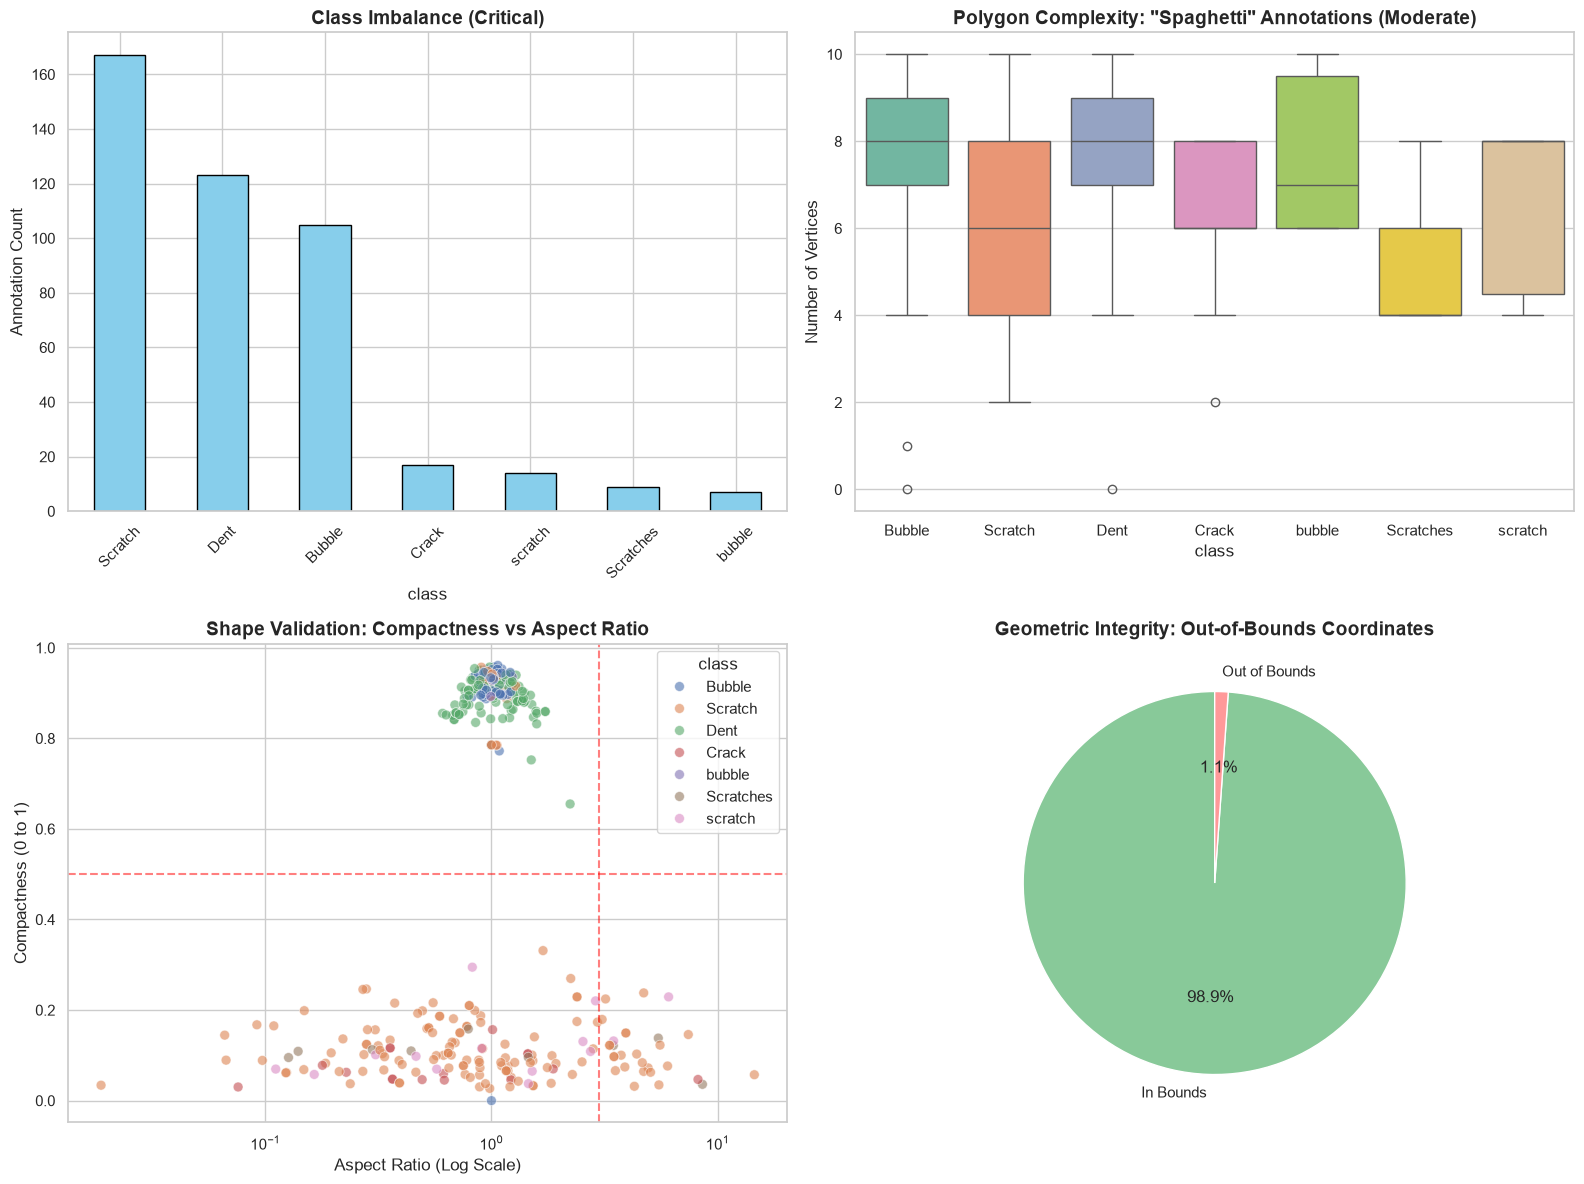

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Class Imbalance
class_dist.plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Class Imbalance (Critical)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Annotation Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Polygon Complexity by Class
sns.boxplot(x='class', y='vertex_count', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Polygon Complexity: "Spaghetti" Annotations (Moderate)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Vertices')

# Chart 3: Compactness vs Aspect Ratio (The "Mic Drop" Chart)
sns.scatterplot(
    x='aspect_ratio', y='compactness', hue='class', 
    data=df, alpha=0.6, ax=axes[1, 0], palette='deep', s=50
)
axes[1, 0].set_title('Shape Validation: Compactness vs Aspect Ratio', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Aspect Ratio (Log Scale)')
axes[1, 0].set_xscale('log')
axes[1, 0].set_ylabel('Compactness (0 to 1)')
axes[1, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axvline(3.0, color='red', linestyle='--', alpha=0.5)

# Chart 4: Out of Bounds
oob_counts = df['out_of_bounds'].value_counts()
axes[1, 1].pie(oob_counts, labels=['In Bounds', 'Out of Bounds'], autopct='%1.1f%%', colors=['#88c999', '#ff9999'], startangle=90)
axes[1, 1].set_title('Geometric Integrity: Out-of-Bounds Coordinates', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Executive Visualizations for Stakeholder Review
* **Strategic Color Mapping:** Using corporate blue for baseline metrics and high-visibility red/orange to instantly draw the stakeholder's eye to the exact data point representing risk.
* **Contextual Annotations:** Adding direct text callouts on the charts (e.g., "Expected Zone" vs "Actual Data") so non-technical leaders don't have to guess how to interpret the axes.
* **Business-First Framing:** Translating raw statistical anomalies (like aspect ratios) into visual proof of the "Blob Effect" and structural risk.

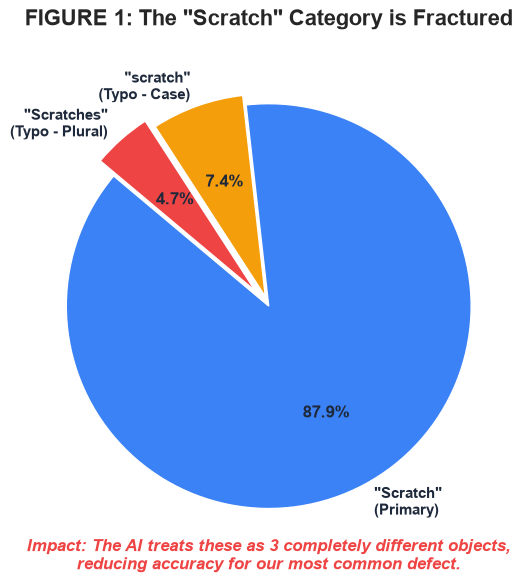

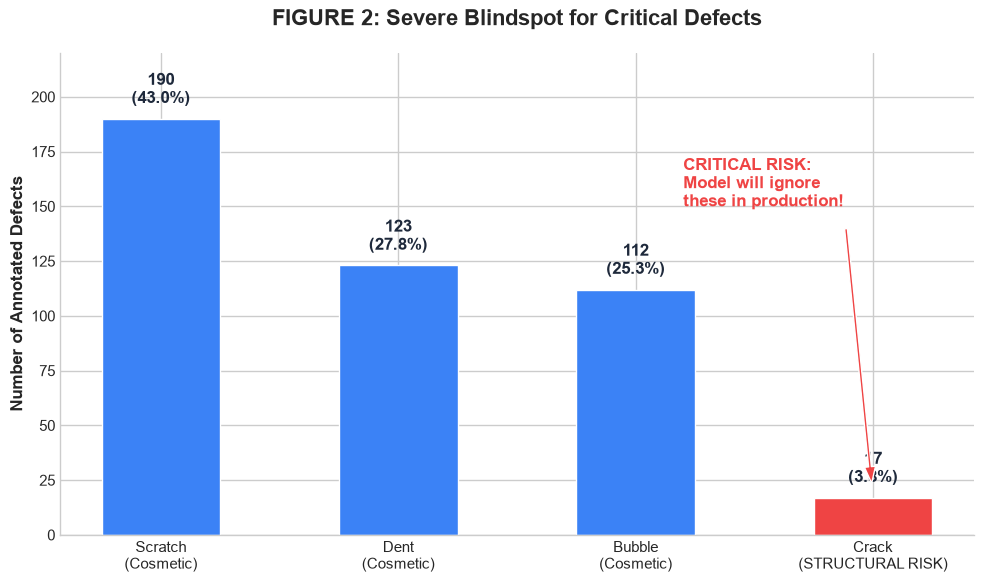

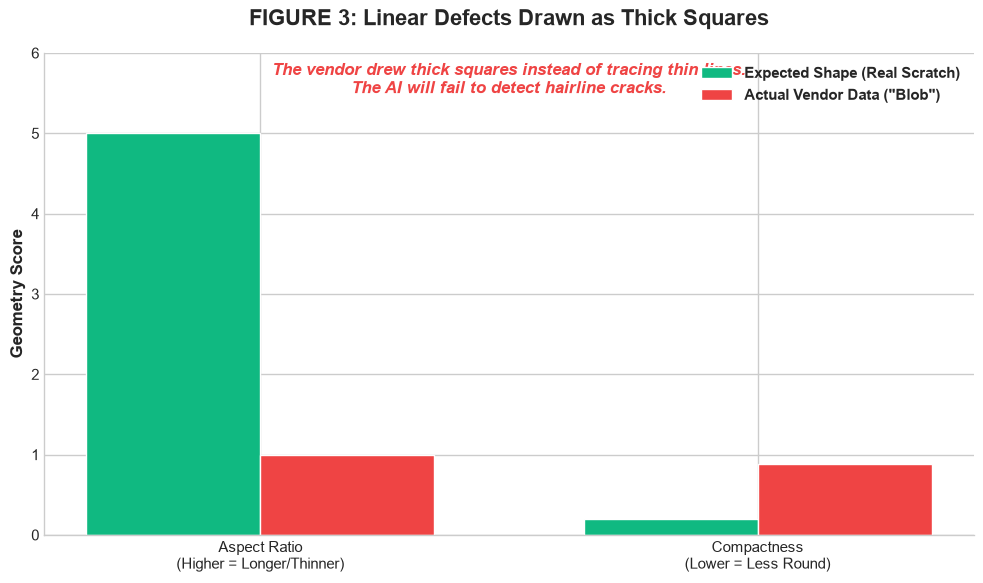

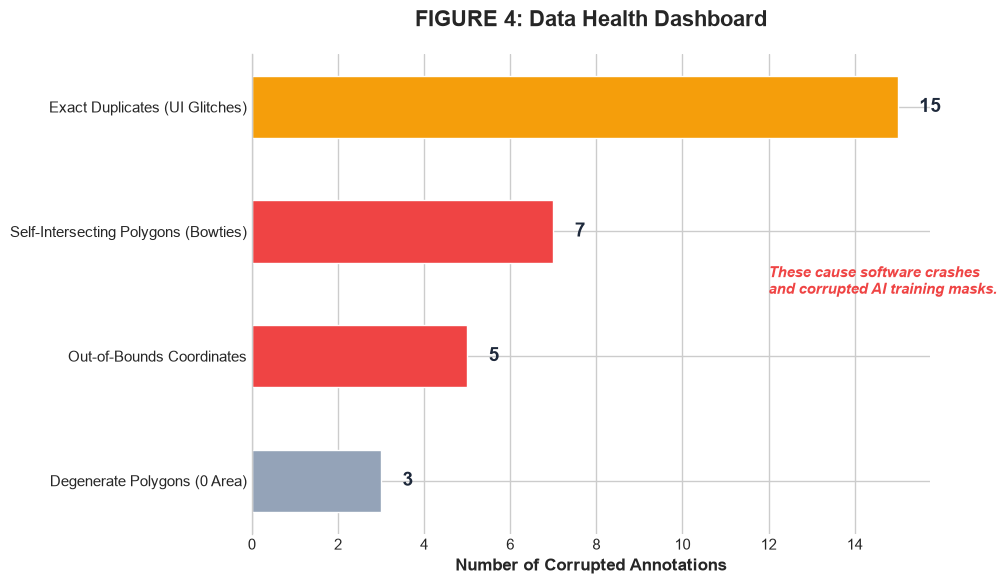

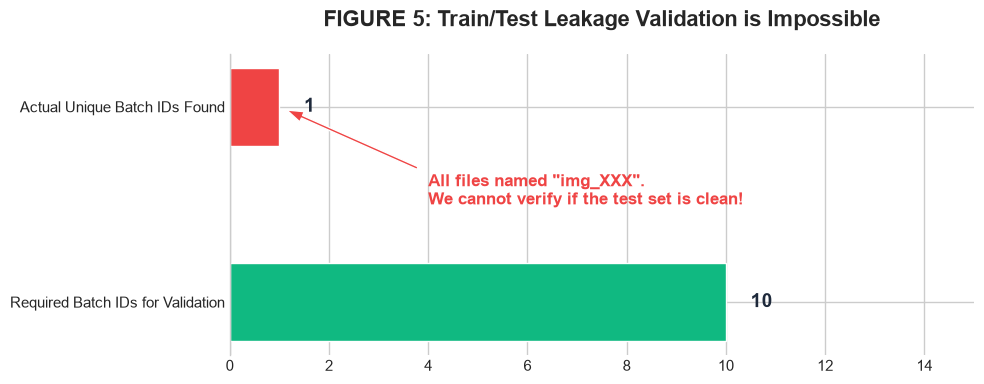

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Set modern, clean style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Modern Corporate Palette (Tailwind-inspired)
COLOR_DARK = '#1e293b'   # Slate 800 (Text)
COLOR_BLUE = '#3b82f6'   # Blue 500 (Primary)
COLOR_GREEN = '#10b981'  # Emerald 500 (Good/Expected)
COLOR_AMBER = '#f59e0b'  # Amber 500 (Warning)
COLOR_RED = '#ef4444'    # Rose 500 (Critical Risk)
COLOR_GRAY = '#94a3b8'   # Slate 400 (Neutral)

# =====================================================================
# FIGURE 1: Label Inconsistency (The Fragmentation Problem)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor('white')

labels = ['"Scratch"\n(Primary)', '"scratch"\n(Typo - Case)', '"Scratches"\n(Typo - Plural)']
sizes = [167, 14, 9]
colors = [COLOR_BLUE, COLOR_AMBER, COLOR_RED]
explode = (0, 0.05, 0.1) # Pop out the typos

wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
                                   colors=colors, startangle=140, textprops={'color': COLOR_DARK, 'fontweight': 'bold'})

ax1.set_title('FIGURE 1: The "Scratch" Category is Fractured', pad=20)
ax1.text(0, -1.3, 'Impact: The AI treats these as 3 completely different objects,\nreducing accuracy for our most common defect.', 
         ha='center', fontsize=12, color=COLOR_RED, fontweight='bold', style='italic')

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: Severe Class Imbalance (The Missing Crack Problem)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor('white')

classes = ['Scratch\n(Cosmetic)', 'Dent\n(Cosmetic)', 'Bubble\n(Cosmetic)', 'Crack\n(STRUCTURAL RISK)']
counts = [190, 123, 112, 17]
colors = [COLOR_BLUE, COLOR_BLUE, COLOR_BLUE, COLOR_RED]

bars = ax2.bar(classes, counts, color=colors, width=0.5, edgecolor='white')
ax2.set_ylabel('Number of Annotated Defects', fontweight='bold')
ax2.set_title('FIGURE 2: Severe Blindspot for Critical Defects', pad=20)
ax2.set_ylim(0, 220)

# Add percentage labels
for bar, count in zip(bars, counts):
    pct = (count / sum(counts)) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{count}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontweight='bold', color=COLOR_DARK)

ax2.annotate('CRITICAL RISK:\nModel will ignore\nthese in production!', 
             xy=(3, 17), xytext=(2.2, 150),
             arrowprops=dict(facecolor=COLOR_RED, shrink=0.05, width=2, headwidth=8),
             fontsize=12, color=COLOR_RED, fontweight='bold')

# Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 3: The "Blob Effect" (Expected vs Actual)
# =====================================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.patch.set_facecolor('white')

metrics = ['Aspect Ratio\n(Higher = Longer/Thinner)', 'Compactness\n(Lower = Less Round)']
expected = [5.0, 0.2]  # What a real scratch looks like
actual = [1.0, 0.88]   # What the vendor drew

x = np.arange(len(metrics))
width = 0.35

bars1 = ax3.bar(x - width/2, expected, width, label='Expected Shape (Real Scratch)', color=COLOR_GREEN, edgecolor='white')
bars2 = ax3.bar(x + width/2, actual, width, label='Actual Vendor Data ("Blob")', color=COLOR_RED, edgecolor='white')

ax3.set_ylabel('Geometry Score', fontweight='bold')
ax3.set_title('FIGURE 3: Linear Defects Drawn as Thick Squares', pad=20)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)

# FIX: Use 'prop' dictionary for legend font styling
ax3.legend(loc='upper right', frameon=False, prop={'weight': 'bold'}) 

ax3.set_ylim(0, 6)

ax3.text(0.5, 5.5, 'The vendor drew thick squares instead of tracing thin lines.\nThe AI will fail to detect hairline cracks.', 
         ha='center', fontsize=12, color=COLOR_RED, fontweight='bold', style='italic')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 4: Data Integrity Dashboard (Corrupted Masks)
# =====================================================================
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.patch.set_facecolor('white')

issues = ['Exact Duplicates (UI Glitches)', 'Self-Intersecting Polygons (Bowties)', 'Out-of-Bounds Coordinates', 'Degenerate Polygons (0 Area)']
counts = [15, 7, 5, 3]
colors = [COLOR_AMBER, COLOR_RED, COLOR_RED, COLOR_GRAY]

bars = ax4.barh(issues, counts, color=colors, height=0.5, edgecolor='white')
ax4.set_xlabel('Number of Corrupted Annotations', fontweight='bold')
ax4.set_title('FIGURE 4: Data Health Dashboard', pad=20)
ax4.invert_yaxis()

for bar, count in zip(bars, counts):
    ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(count), 
             va='center', fontweight='bold', fontsize=14, color=COLOR_DARK)

ax4.text(12, 1.5, 'These cause software crashes\nand corrupted AI training masks.', 
         color=COLOR_RED, fontweight='bold', fontsize=11, style='italic')

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['bottom'].set_visible(False) # Clean look

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 5: Metadata & Leakage Check (The Blindspot)
# =====================================================================
fig5, ax5 = plt.subplots(figsize=(10, 4))
fig5.patch.set_facecolor('white')

# Create a progress bar style chart
categories = ['Required Batch IDs for Validation', 'Actual Unique Batch IDs Found']
values = [10, 1] # 10 is arbitrary "good" baseline, 1 is actual
colors = [COLOR_GREEN, COLOR_RED]

bars = ax5.barh(categories, values, color=colors, height=0.4, edgecolor='white')
ax5.set_xlim(0, 15)
ax5.set_title('FIGURE 5: Train/Test Leakage Validation is Impossible', pad=20)

for bar, val in zip(bars, values):
    ax5.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), 
             va='center', fontweight='bold', fontsize=14, color=COLOR_DARK)

ax5.annotate('All files named "img_XXX".\nWe cannot verify if the test set is clean!', 
             xy=(1, 1), xytext=(4, 0.5),
             arrowprops=dict(facecolor=COLOR_RED, shrink=0.05, width=2, headwidth=8),
             fontsize=12, color=COLOR_RED, fontweight='bold')

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

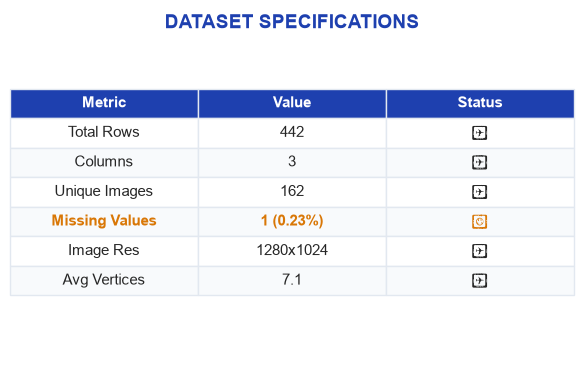

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4)) # Wide aspect ratio for the white box
fig.patch.set_facecolor('white')
ax.axis('off')

# Title for the table
ax.text(0.5, 0.95, 'DATASET SPECIFICATIONS', 
        fontsize=14, fontweight='bold', ha='center', color='#1E40AF')

# Table data
columns = ['Metric', 'Value', 'Status']
data = [
    ['Total Rows', '442', '✓'],
    ['Columns', '3', '✓'],
    ['Unique Images', '162', '✓'],
    ['Missing Values', '1 (0.23%)', '⚠'],
    ['Image Res', '1280x1024', '✓'],
    ['Avg Vertices', '7.1', '✓']
]

# Create table
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# Style the table
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#E2E8F0')
    if row == 0: # Header row
        cell.set_facecolor('#1E40AF')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F8FAFC' if row % 2 == 0 else 'white')
        # Highlight the warning row
        if row == 4: 
            cell.set_text_props(color='#D97706', fontweight='bold')

plt.tight_layout()
plt.savefig('slide2_spec_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()